# 13 · E3d: does the drift wander or return?

**Where E3c left off (Notebook 12, 68 Atanas et al. recordings).** The drift has the profile of **slow changes of each neuron's drive**:
* no detectable gain, low-rank or coupling structure (the only family that passed, `dense`, passes equally on drive-only surrogates);
* not shared across neurons beyond what independent drift produces;
* not the microscope (no correlation with signal fading; measurement corrections make forecasts worse).

What imaging can still tell about such drift is its **time structure**:

| | the drives… | meaning for C3 |
|---|---|---|
| **wander** | do a random walk: no set point within the ~17-min recording | the hardware is rewritten by something with no restoring force at this timescale |
| **return** | fluctuate around set points with a time constant τ (an Ornstein–Uhlenbeck process) | a slower regulating layer keeps the hardware near a fixed program: homeostasis of the drives, the drive-level analogue of the ladder's L4 |

A second question: **can the drift be tracked online by one fixed rule?** Each neuron's drive follows its own past prediction errors with one time constant, chosen on the past. If this tracker forecasts as well as re-estimating N drives per window, the drift is a *state* of the system rather than a rewrite. It is one slow hidden state per neuron, driven by input the program does not explain.

**What the synthetic checks showed while building this (one recording).**
* **Fitting the program on the whole recording hides the drift.** Each neuron's own level tracks its drive, so self- and coupling terms absorb slow drive changes, and drives re-estimated under that program barely vary, even in random-walk surrogates.
  * The drives are therefore estimated with the **within-window (fixed-effects) estimator**: couplings are fitted on within-window fluctuations, one drive per window. This probably also explains why `dense` gained on drive-only drift in E3c: a richer coupling update can follow a drifting state.
* With that estimator, OU surrogates with τ = 3 min were recovered at 2.7–5.5 min on one recording (across all 68 the median was 1.0 min: the estimate is biased low, see Results), random walks at 5–27 min, and stationary surrogates at ~0.7 min (the program's own slow fluctuations).
* Single recordings are noisy: an OU surrogate with τ = 10 min ranged from 7.6 to 240 min. Over 10 paired draws on one recording, the OU(3 min) surrogate got the smaller τ in 8.
* A random walk observed for only ~17 min fits τ ≈ 3–14 min (median 6.5). **Absolute τ values are therefore not interpretable on their own**; only the comparison with each recording's own random-walk surrogate is. Every rule is a test over recordings, paired against those surrogates.
* **The tracker's time constant must be chosen honestly.** A program's residuals on its own training data have zero mean, which always favours the slowest tracker. It is chosen with a program fitted on the earlier part of the past and scored on the later part.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, glob, time, datetime, numpy as np, matplotlib.pyplot as plt
from scipy.stats import wilcoxon
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:3]) >= (0, 12, 0), \
    f"Notebook 13 needs closurebench >= 0.12.0 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import drift as DR, drift_kinds as DK, drift_time as DT
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CONF = {"smoke": dict(N_NULL=1, MAX_FILES=1), "laptop": dict(N_NULL=2, MAX_FILES=None), "full": dict(N_NULL=3, MAX_FILES=None)}[MODE]
globals().update(CONF)
K_WIN, OU_TAU, GAP_FLOOR, ABSORB_MIN = 16, 3.0, 0.005, 0.5
TAG = "" if MODE == "full" else f"_{MODE}"
files = sorted(glob.glob(os.path.join(RESULTS, "spontaneous", "*.json")))[:MAX_FILES]
CK = os.path.join(RESULTS, "e3d_ck", MODE); os.makedirs(CK, exist_ok=True)
E3C_CK = os.path.join(RESULTS, "e3c_ck", MODE)      # drift detection is reused from Notebook 12 when available
print(f"{len(files)} recordings; {K_WIN} windows; {N_NULL} stationary + 1 random-walk + 1 OU(τ = {OU_TAU} min) surrogate each")
print("E3c checkpoints:", "found" if os.path.isdir(E3C_CK) and os.listdir(E3C_CK) else "not found (drift detection recomputed)")

68 recordings; 16 windows; 2 stationary + 1 random-walk + 1 OU(τ = 3.0 min) surrogate each
E3c checkpoints: found


### Pre-registration (before §1)

Recorded in `results/E3d_preregistration*.json`.

**Drift-detected recordings** are defined as in Notebooks 10–12: refit − frozen gap ≥ max(0.005, the largest stationary-surrogate gap). Detection is taken from Notebook 12's checkpoints when present.

**Drift time constant.** For each recording:
* The drives are estimated in 16 windows (~1 min each) with the within-window estimator.
* Their semivariance is computed against lag.
* The fitted model is nugget + fast term + sill·(1 − e^(−h/τ)). The fast time constant comes from the recording's stationary surrogates; τ is searched on a 0.5–240 min grid.

The rules:
* **VALID.** The method tells "return" from "wander": τ of the OU(3 min) surrogates < τ of the random-walk surrogates. One-sided paired Wilcoxon on log τ over recordings, p < 0.05.
* **RETURN** (homeostatic drives). Over drift-detected recordings, τ_real < τ of the recording's random-walk surrogate (one-sided paired Wilcoxon on log τ, p < 0.05). Read only if VALID.
* **TRACKABLE.** Over drift-detected recordings, the median absorption by the online tracker, (tracker − frozen)/(refit − frozen), is ≥ 0.5. As a positive control, the same median is reported on random-walk surrogates where drift was detected.

In [3]:
prereg = os.path.join(RESULTS, f"E3d_preregistration{TAG}.json")
plan = {"experiment": "E3d wander or return", "mode": MODE, "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(),
        "config": {**CONF, "K_WIN": K_WIN, "OU_TAU": OU_TAU, "GAP_FLOOR": GAP_FLOOR, "ABSORB_MIN": ABSORB_MIN,
                   "tau_grid_min": [float(DT.TAU_GRID_MIN[0]), float(DT.TAU_GRID_MIN[-1])], "track_taus": list(DT.TRACK_TAUS)},
        "detected": "gap >= max(GAP_FLOOR, max stationary-surrogate gap) (Notebook 12 checkpoints if present)",
        "VALID": "one-sided paired Wilcoxon log tau_OU < log tau_RW over recordings, p < 0.05",
        "RETURN": "one-sided paired Wilcoxon log tau_real < log tau_RW over detected, p < 0.05; read only if VALID",
        "TRACKABLE": "median over detected of (tracker - frozen)/(refit - frozen) >= 0.5"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E3d_preregistration_laptop.json


## 1 · Per-recording analysis (checkpointed)

About a minute per recording on a laptop. Each recording is saved as soon as it is done, so a re-run resumes.

In [4]:
def vgram(Y, S, U):
    V, n = DT.variogram(DT.drive_series(Y, S, U, K_WIN)); return V, n

rec = {}
for f in files:
    name = os.path.basename(f).replace(".json", "")[-13:]
    ck = os.path.join(CK, name + ".json")
    if os.path.exists(ck):
        rec[name] = json.load(open(ck)); continue
    t0 = time.time()
    R = DR.load_atanas(f); X, U, dt = R["X"], R["U"], R["dt"]
    S = ~np.eye(X.shape[1], dtype=bool)
    win = len(X) * dt / K_WIN / 60.0
    Yn = [Y for Y in (DR.surrogate(X, S, U, seed=400 + s) for s in range(N_NULL)) if Y is not None]
    nulls = [vgram(Y, S, U) for Y in Yn]
    tf = float(np.mean([DT.fit_variogram(V, win, n)["tau"] for V, n in nulls])) if nulls else None
    out = {"N": int(X.shape[1]), "win_min": win, "tau_fast": tf, "null_V": [V.tolist() for V, _ in nulls], "series": {}}
    e3c = os.path.join(E3C_CK, name + ".json")
    if os.path.exists(e3c):
        o = json.load(open(e3c)); out["gap"] = o["real"]["gap"]; out["thr"] = max([GAP_FLOOR] + [n["gap"] for n in o["null"]])
    else:
        out["gap"] = DK.family_scores(X, S, U, families=("bias",))["gap"]
        out["thr"] = max([GAP_FLOOR] + [DK.family_scores(Y, S, U, families=("bias",))["gap"] for Y in Yn])
    for key, Y in [("real", X), ("rw", DR.surrogate(X, S, U, seed=500, drift_frac=0.07)),
                   ("ou", DT.ou_surrogate(X, S, U, dt=dt, tau_min=OU_TAU, seed=600))]:
        if Y is None:
            continue
        V, n = vgram(Y, S, U)
        s = {"V": V.tolist(), "fit": DT.fit_variogram(V, win, n, tau_fast=tf), "G": DT.growth_ratio(V)}
        if key in ("real", "rw"):
            s["track"] = DT.tracker_scores(Y, S, U)
        out["series"][key] = s
    json.dump(out, open(ck, "w"), default=float); rec[name] = out
    sr = out["series"]
    print(f"{name}: gap {out['gap']:+.4f} (thr {out['thr']:.4f}) | tau real {sr['real']['fit']['tau']:6.1f} min"
          + (f", RW {sr['rw']['fit']['tau']:6.1f}" if "rw" in sr else "") + (f", OU {sr['ou']['fit']['tau']:6.1f}" if "ou" in sr else "")
          + f" | tracker absorbs {sr['real']['track']['absorbed']:+.2f}  ({time.time() - t0:.0f} s)", flush=True)
print(f"{len(rec)} recordings analysed")

2021-05-26-07: gap +0.0043 (thr 0.0050) | tau real    4.5 min, RW    4.5, OU    9.4 | tracker absorbs +0.72  (25 s)
2021-06-11-01: gap +0.0212 (thr 0.0054) | tau real    8.4 min, RW   40.5, OU  240.0 | tracker absorbs +2.26  (33 s)
2021-08-04-06: gap +0.0050 (thr 0.0050) | tau real    3.0 min, RW    5.0, OU    0.5 | tracker absorbs +1.49  (32 s)
2021-08-17-01: gap +0.0208 (thr 0.0050) | tau real    1.2 min, RW    0.6, OU    0.5 | tracker absorbs +0.85  (34 s)
2021-08-18-01: gap +0.0243 (thr 0.0050) | tau real    6.2 min, RW    2.4, OU    0.9 | tracker absorbs +1.51  (28 s)
2021-09-06-09: gap +0.0049 (thr 0.0050) | tau real    3.3 min, RW    2.7, OU  240.0 | tracker absorbs +4.21  (28 s)
2021-09-14-01: gap +0.0625 (thr 0.0050) | tau real    0.7 min, RW    0.9, OU    0.5 | tracker absorbs +1.54  (27 s)
2021-09-14-05: gap +0.0030 (thr 0.0050) | tau real    5.0 min, RW    0.8, OU   32.9 | tracker absorbs +2.22  (30 s)
2021-09-22-05: gap +0.0417 (thr 0.0050) | tau real    1.0 min, RW   10.4

In [5]:
def wtest(x, alt="greater"):
    x = np.asarray(x, float)
    return float(wilcoxon(x, alternative=alt).pvalue) if len(x) >= 6 and np.any(x != 0) else float("nan")
ltau = lambda o, k: np.log(o["series"][k]["fit"]["tau"])
det = {k: o for k, o in rec.items() if o["gap"] >= o["thr"]}
both = {k: o for k, o in rec.items() if "rw" in o["series"] and "ou" in o["series"]}
print(f"drift detected in {len(det)}/{len(rec)} recordings; surrogate pairs available for {len(both)}")

drift detected in 47/68 recordings; surrogate pairs available for 68


## 2 · Control: can the method tell "return" from "wander"? (VALID)

In [6]:
d_ctrl = [ltau(o, "ou") - ltau(o, "rw") for o in both.values()]
p_valid = wtest(d_ctrl, "less")
VALID = bool(p_valid < 0.05)
med = lambda k, src: float(np.median([o["series"][k]["fit"]["tau"] for o in src.values() if k in o["series"]])) if src else float("nan")
print(f"median fitted tau: OU surrogates (true {OU_TAU} min) {med('ou', both):.1f} min | random-walk surrogates {med('rw', both):.1f} min")
print(f"OU < RW in {sum(x < 0 for x in d_ctrl)}/{len(d_ctrl)} recordings, Wilcoxon p = {p_valid:.3g} -> VALID: {VALID}")

median fitted tau: OU surrogates (true 3.0 min) 1.0 min | random-walk surrogates 4.1 min
OU < RW in 46/68 recordings, Wilcoxon p = 0.000807 -> VALID: True


## 3 · Wander or return? (RETURN)

median drift tau, detected recordings: real 6.2 min | their RW surrogates 4.1 | their OU(3.0) surrogates 0.9
real < RW in 20/47, Wilcoxon p = 0.779; real vs OU (two-sided, descriptive) p = 0.000679
tau at the top of the grid (no detectable return): real 7/47
Registered rule -> RETURN (homeostatic drives): False 


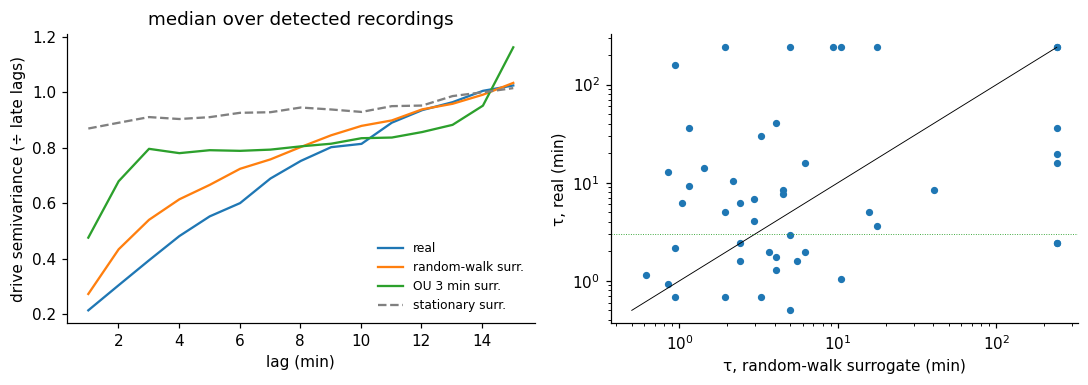

In [7]:
d_ret = [ltau(o, "real") - ltau(o, "rw") for o in det.values() if "rw" in o["series"]]
p_ret = wtest(d_ret, "less")
RETURN = bool(VALID and p_ret < 0.05)
d_ou = [ltau(o, "real") - ltau(o, "ou") for o in det.values() if "ou" in o["series"]]
p_ou = wtest(d_ou, "two-sided")
print(f"median drift tau, detected recordings: real {med('real', det):.1f} min | their RW surrogates {med('rw', det):.1f} | their OU({OU_TAU}) surrogates {med('ou', det):.1f}")
print(f"real < RW in {sum(x < 0 for x in d_ret)}/{len(d_ret)}, Wilcoxon p = {p_ret:.3g}; real vs OU (two-sided, descriptive) p = {p_ou:.3g}")
print(f"tau at the top of the grid (no detectable return): real {sum(o['series']['real']['fit']['at_edge'] for o in det.values())}/{len(det)}")
print("Registered rule -> RETURN (homeostatic drives):", RETURN, "" if VALID else "(not interpretable: VALID is False)")
if det:
    fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
    for k, c, lab in [("real", "tab:blue", "real"), ("rw", "tab:orange", "random-walk surr."), ("ou", "tab:green", f"OU {OU_TAU:g} min surr.")]:
        Vs = [np.asarray(o["series"][k]["V"]) for o in det.values() if k in o["series"]]
        if Vs:
            Vn = np.array([V / V[-3:].mean() for V in Vs])
            h = np.arange(1, Vn.shape[1] + 1) * np.median([o["win_min"] for o in det.values()])
            ax[0].plot(h, np.median(Vn, 0), c=c, label=lab)
    Vs = [np.asarray(V) for o in det.values() for V in o["null_V"]]
    if Vs:
        Vn = np.array([V / V[-3:].mean() for V in Vs]); ax[0].plot(h, np.median(Vn, 0), c="0.5", ls="--", label="stationary surr.")
    ax[0].set_xlabel("lag (min)"); ax[0].set_ylabel("drive semivariance (÷ late lags)"); ax[0].legend(frameon=False, fontsize=8)
    ax[0].set_title("median over detected recordings")
    x = [o["series"]["rw"]["fit"]["tau"] for o in det.values() if "rw" in o["series"]]
    y = [o["series"]["real"]["fit"]["tau"] for o in det.values() if "rw" in o["series"]]
    ax[1].scatter(x, y, s=14); ax[1].set_xscale("log"); ax[1].set_yscale("log")
    lim = [DT.TAU_GRID_MIN[0], DT.TAU_GRID_MIN[-1]]; ax[1].plot(lim, lim, "k-", lw=0.6)
    ax[1].axhline(OU_TAU, c="tab:green", lw=0.6, ls=":"); ax[1].set_xlabel("τ, random-walk surrogate (min)"); ax[1].set_ylabel("τ, real (min)")
    plt.tight_layout(); plt.show()

## 4 · Can one online rule track the drift? (TRACKABLE)

tracker absorption, median: real +1.67 (47 detected) | random-walk surrogates +0.84 (33 detected)
absorbs >= 0.5 in 47/47 real recordings; tracker beats the per-window refit in 42/47
chosen tracker time constants (frames): {16: 16, 32: 56, 64: 13, 128: 43, 256: 54, 512: 5, 1024: 1}
Registered rule -> TRACKABLE: True


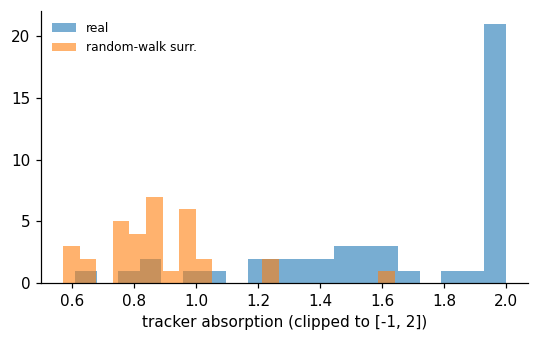

In [8]:
ab = [o["series"]["real"]["track"]["absorbed"] for o in det.values()]
ab_rw = [o["series"]["rw"]["track"]["absorbed"] for o in rec.values() if "rw" in o["series"] and o["series"]["rw"]["track"]["gap"] >= o["thr"]]
TRACKABLE = bool(len(ab) and np.nanmedian(ab) >= ABSORB_MIN)
taus = [t for o in det.values() for t in o["series"]["real"]["track"]["taus_chosen"]]
print(f"tracker absorption, median: real {np.nanmedian(ab) if ab else float('nan'):+.2f} ({len(ab)} detected) | random-walk surrogates {np.nanmedian(ab_rw) if ab_rw else float('nan'):+.2f} ({len(ab_rw)} detected)")
print(f"absorbs >= {ABSORB_MIN} in {sum(a >= ABSORB_MIN for a in ab)}/{len(ab)} real recordings; tracker beats the per-window refit in {sum(a > 1 for a in ab)}/{len(ab)}")
if taus:
    print("chosen tracker time constants (frames):", {int(t): taus.count(t) for t in sorted(set(taus))})
print("Registered rule -> TRACKABLE:", TRACKABLE)
if ab:
    fig, ax = plt.subplots(figsize=(5, 3.2))
    ax.hist(np.clip(ab, -1, 2), bins=20, alpha=0.6, label="real"); ax.hist(np.clip(ab_rw, -1, 2), bins=20, alpha=0.6, label="random-walk surr.")
    ax.axvline(ABSORB_MIN, c="k", lw=0.6, ls="--"); ax.set_xlabel("tracker absorption (clipped to [-1, 2])"); ax.legend(frameon=False, fontsize=8)
    plt.tight_layout(); plt.show()

## 5 · Re-checking E3c's dimensionality result (exploratory, not registered)

E3c's LOW_DIM rule compared the PC1 share of the drive changes with *stationary* surrogates. Independent per-neuron drift also raises it, so the right comparison is the drive-drift surrogate. This cell uses Notebook 12's checkpoints.

In [9]:
pairs = []
for name in det:
    fck = os.path.join(E3C_CK, name + ".json")
    if os.path.exists(fck):
        o = json.load(open(fck))
        if o.get("drive_drift"):
            pairs.append((o["real"]["pc1"], o["drive_drift"]["pc1"]))
if len(pairs) >= 6:
    pr, pd = map(np.array, zip(*pairs))
    print(f"PC1 share: real {np.median(pr):.2f} vs drive-drift surrogate {np.median(pd):.2f}; real > surrogate in {(pr > pd).sum()}/{len(pr)}; "
          f"two-sided Wilcoxon p = {wtest(pr - pd, 'two-sided'):.3g}")
else:
    print("Notebook 12 checkpoints not found; skipped")

PC1 share: real 0.29 vs drive-drift surrogate 0.31; real > surrogate in 20/47; two-sided Wilcoxon p = 0.138


In [10]:
out = {"n": len(rec), "detected": len(det),
       "VALID": {"p": p_valid, "valid": VALID, "median_tau_ou": med("ou", both), "median_tau_rw": med("rw", both)},
       "RETURN": {"p": p_ret, "return": RETURN, "median_tau_real": med("real", det), "median_tau_rw_detected": med("rw", det),
                  "p_vs_ou_two_sided": p_ou},
       "TRACKABLE": {"median_absorbed": float(np.nanmedian(ab)) if ab else None,
                     "median_absorbed_rw": float(np.nanmedian(ab_rw)) if ab_rw else None, "trackable": TRACKABLE},
       "per_recording": rec}
json.dump(out, open(os.path.join(RESULTS, f"E3d_result{TAG}.json"), "w"), indent=2, default=float)
print("saved", f"E3d_result{TAG}.json")

saved E3d_result_laptop.json


## Results (laptop mode, 68 recordings, executed on the M1)

Drift was detected in 47/68 recordings, the same set as in Notebooks 10–12.

**VALID: yes, but the τ estimate is biased low.**
* The OU(3 min) surrogates got a smaller τ than their random-walk partners in 46/68 recordings (Wilcoxon p = 0.0008). The method separates return from wander at the population level.
* The fitted values are biased: median 1.0 min for a true 3 min, often at the grid floor (0.5 min); random walks give a median of 4.1 min.
* As anticipated, only the *paired comparison* is interpretable, not the absolute τ.

**RETURN: no. The drives wander.**

| detected recordings | median τ |
|---|---|
| real | 6.2 min |
| their random-walk surrogates | 4.1 min |
| their OU(3 min) surrogates | 0.9 min |

* The real τ is *not* shorter than the random walk's (real < RW in 20/47, p = 0.78).
* It is clearly longer than the OU surrogates' (two-sided p = 0.0007).
* In 7/47 recordings, no return at all is detectable (τ at the top of the grid).
* Within ~17 minutes, nothing pulls the drives back to set points. Their time structure is that of a random walk, not of homeostatic regulation.

**TRACKABLE: yes, by a wide margin, with a caveat.**
* The online tracker absorbs a median of **1.67** of the drift gap: it is at least half as good as the per-window refit in 47/47 recordings, and better than the refit in 42/47. On random-walk surrogates it absorbs 0.84.
* An absorption above 1, and many short chosen time constants (16–32 frames, i.e. 10–20 s, in 72 of 188 forecast windows), mean the tracker also exploits **autocorrelated residuals**: input the program misses on timescales of seconds to a minute, not only the slow drift.
* The surrogates' residual noise is white by construction, so this part has no control in this notebook. Notebook 14 adds one: stationary surrogates whose residuals have the real recording's autocorrelation.

**E3c's dimensionality, re-checked against the right null** (exploratory): the real PC1 share is 0.29 vs 0.31 for the drive-drift surrogates (real > surrogate in 20/47, p = 0.14). The drive changes are **not** more shared across neurons than independent drift. This confirms the reading in Notebook 12.

**Outcome: the second row of the table below** (RETURN no, TRACKABLE yes).

**What E3 (Notebooks 10–13) concludes.** In spontaneous activity, the connectome-free program fitted to the recorded neurons:
* goes stale in ~70 % of worms;
* not through any compact rule driven by recorded activity (10);
* not through changes in identified encoding neurons or slow behavioral state (11);
* not through gain, low-rank or coupling changes, and not through the microscope (12).

What changes is **each neuron's drive, independently, as a random walk with no set point at this timescale (13)**. It can be followed online only from the program's own errors, i.e. from input the recorded network does not explain.

For C3, the "hardware" that gets rewritten is the cheapest kind: each neuron's operating point, set from outside the ~120–150 recorded neurons.

> **Caveat (found while building Notebook 14).** All drift thresholds in Notebooks 10–13 came from surrogates driven by *white* noise. On one recording, stationary surrogates driven by the real residuals' fast (< 1 min) autocorrelation produced refit gaps (+0.007 to +0.023) and tracker gains as large as the real ones. The gap-based results above (detection counts, E3c's families, the tracker) may therefore partly reflect colored input rather than drift. The distance-based staleness slope is not affected. **Notebook 14 re-tests E3 against colored nulls**; read this summary together with its result.
>
> **Resolved (Notebook 14):** that recording was atypical. Across all 68, colored nulls give a median gap of −0.0014, and the real gap, staleness and tracker gain all exceed them (62/68, 64/68, 66/68; p ≤ 10⁻¹¹). The results above stand.

## 6 · Reading the result

| RETURN | TRACKABLE | reading for C3 |
|---|---|---|
| yes | yes | Each neuron's drive is a slow state that fluctuates around a set point with time constant τ, and one fixed rule tracks it. The system is closed as **program + one regulated slow state per neuron**: a homeostatic hardware layer. The computer metaphor survives, with a program that includes its own slow regulation. It is not *compact*, though: N states, not the d ≤ 4 that Notebook 10 allowed. |
| **no ← observed** | **yes ← observed** | The drives wander with no set point within ~17 min, and they can be followed online only from the program's own errors, i.e. from input the program does not explain. The hardware is rewritten from outside the recorded network (unrecorded neurons, neuromodulators, internal state). This is the reading closest to Brette's. |
| yes / no | no | The drift is not trackable by one rule with one time constant: it changes faster or more irregularly than the tracker can follow. Per-window rewriting remains the only description. |
| — (VALID fails) | | 17-min recordings cannot separate return from wander at this drift size; longer recordings are needed. |

**What closes here.** With E3d, the E3 arc (Notebooks 10–13) has gone as far as spontaneous imaging can take it. Recorded activity alone cannot say *what* sets the drives. Telling a regulated program from an externally rewritten one needs **perturbation**: push a neuron's drive and watch whether it returns, which is E4's embodied/perturbation design, or use longer recordings.

**Limits.**
* τ per recording is noisy (one surrogate of each kind per recording); only the population tests are interpretable, and only relative to the random-walk surrogates (a 17-min random walk itself fits τ of a few minutes).
* The window length (~1 min) sets the shortest detectable τ, and the recording (~17 min) the longest. "Wander" means "no return within ~17 min".
* Connectome-free, as in Notebooks 10–12.